                                           Healthcare Industry – Multiple Sclerosis Researchers

Introduction

This dataset presents a structured overview of top researchers in the healthcare industry who
specialize in Multiple Sclerosis (MS). It is designed to support medical affairs, clinical
development, market access, and research strategy teams by identifying key experts and
understanding their level of engagement across scientific and clinical activities.

Dataset Description

This dataset provides a comprehensive overview of researchers specializing in Multiple Sclerosis (MS) within the healthcare domain. It contains detailed information about each researcher’s professional background, geographic location, and level of engagement across a wide range of scientific and clinical activities. The dataset is structured in a way that enables meaningful analysis of researcher performance and expertise.

Each record represents an individual researcher and includes key profile information such as name, specialty, and primary as well as secondary affiliations. In addition, it captures geographic details like country and state, which allow for regional and global analysis of expertise distribution. This information is useful for understanding where major concentrations of MS research activity exist.

The dataset also includes multiple activity and performance metrics that reflect the level of engagement of each researcher. These include the total number of activities captured, number of publications, congress participation points, involvement in clinical guidelines, editorial board memberships, organizational roles, and participation in clinical trials. Together, these metrics help assess the overall contribution and influence of researchers in the field.

Furthermore, the dataset provides topic-specific insights by capturing researcher activity across various Multiple Sclerosis-related domains. These topics include prognostic evaluation, novel and existing therapies, biomarker research, inflammation, epidemiology, and unmet medical needs. For each topic, activity is further divided into contributions made through congress participation and scientific publications, enabling deeper comparative analysis.

Overall, this dataset is designed to support healthcare analytics by identifying key opinion leaders, analyzing research activity patterns, understanding geographic distribution of expertise, and assisting in strategic decision-making for clinical development and medical affairs.

Problem Statement

The healthcare industry relies on identifying Key Opinion Leaders (KOLs) and understanding research activity trends to support clinical development, 
medical affairs strategy, and collaboration.
    
This project aims to analyze a dataset of Multiple Sclerosis (MS) researchers to:

1- Identify highly influential researchers based on activity and normalized ranking
2 -Understand distribution of expertise across regions and institutions
3 -Analyze research activity patterns such as publications, clinical trials, and congress participation
4 -Discover relationships between different types of professional activities

Objective of Analysis

The main goal of this project is to perform exploratory data analysis (EDA) to:

Identify top-performing MS researchers

Analyze activity trends across different categories

Understand geographic distribution of expertise

Generate insights that can support healthcare decision-making

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_excel("MS Standard Export.xlsx")

# Check if loaded properly
df.head()

,Unique Id,Last Name,First Name,Initial,Qualification,Country,State / Region / Province,City,Affiliation1,Affiliation2,...,a. Progressive Multiple Sclerosis_Congress,a. Progressive Multiple Sclerosis_Journal,a. Bruton tyrosine kinase (BTK) inhibitors_Congress,a. Bruton tyrosine kinase (BTK) inhibitors_Journal,a. CAR T cell therapy_Congress,a. CAR T cell therapy_Journal,a. Monoclonal antibodies_Congress,a. Monoclonal antibodies_Journal,a. CD20 focused_Congress,a. CD20 focused_Journal
0,37959917,Filippi,Massimo,M,NaN,Italy,Lombardia,Città Metropolitana di Milano,Vita-Salute San Raffaele University,NaN,...,61.0,18,NaN,2,NaN,0,34.0,32,28.0,15
1,37972618,Kappos,Ludwig,L,"MD, Dipl.-Psych., FEAN, FAAN",Switzerland,Basel-Stadt,Basel,University of Basel,NaN,...,34.0,14,9.0,1,NaN,0,40.0,23,41.0,25
2,37986469,Montalban,Xavier,X,"MD, PhD, FAAN, FEAN, FCAHS",Spain,Cataluña,Barcelona,Vall d’Hebron University Hospital,Universitat Autònoma de Barcelona,...,31.0,5,34.0,6,NaN,0,28.0,21,24.0,17
3,37997961,Rocca,Maria A,MA,MD,Italy,Lazio,Roma,IRCCS San Raffaele Scientific Institute,Vita-Salute San Raffaele University,...,39.0,10,NaN,1,NaN,0,8.0,14,7.0,8
4,37976046,Kuhle,Jens,J,"MD, PhD",Switzerland,Basel-Stadt,Basel,University Hospital Basel,NaN,...,34.0,10,6.0,1,NaN,1,16.0,21,16.0,12


In [3]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types
df.dtypes

# Basic info
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78857 entries, 0 to 78856
Data columns (total 89 columns):
 #   Column                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                 --------------  -----  
 0   Unique Id                                                                                              78857 non-null  int64  
 1   Last Name                                                                                              78856 non-null  object 
 2   First Name                                                                                             78819 non-null  object 
 3   Initial                                                                                                78748 non-null  object 
 4   Qualification                                                                                 

,Unique Id,Position based on Normalised Score,TOTAL NUMBER OF ACTIVITIES CAPTURED,Total number of publications-overall,Total number of publications-in the last year,Number of Congress activity points,Total number of sessions,Number of Session Chair Activities,Number of Session Speaker Activities,Total number of Abstracts,...,a. Progressive Multiple Sclerosis_Congress,a. Progressive Multiple Sclerosis_Journal,a. Bruton tyrosine kinase (BTK) inhibitors_Congress,a. Bruton tyrosine kinase (BTK) inhibitors_Journal,a. CAR T cell therapy_Congress,a. CAR T cell therapy_Journal,a. Monoclonal antibodies_Congress,a. Monoclonal antibodies_Journal,a. CD20 focused_Congress,a. CD20 focused_Journal
count,7.885700e+04,78857.000000,78857.000000,78857.000000,78857.000000,78857.000000,78857.000000,78857.000000,78857.000000,78857.000000,...,5342.000000,78857.000000,371.000000,78857.000000,40.000000,78857.00000,4780.000000,78857.000000,4595.000000,78857.000000
mean,3.798218e+07,49.824898,2.506144,1.569144,0.400079,0.882230,0.035812,0.011882,0.023929,0.839406,...,1.781917,0.031361,2.617251,0.005428,1.050000,0.00104,1.837866,0.153354,1.810664,0.093257
std,4.016844e+04,1.432116,7.925564,4.330498,1.246406,3.968642,0.486878,0.204441,0.323527,3.650012,...,2.407974,0.283983,4.038882,0.094196,0.316228,0.03451,2.721092,0.797306,2.639214,0.570421
min,3.793699e+07,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,1.000000,0.000000,1.000000,0.000000
25%,3.795788e+07,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,1.000000,0.000000,1.000000,0.000000
50%,3.797867e+07,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,1.000000,0.000000,1.000000,0.000000
75%,3.799948e+07,50.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,2.000000,0.000000,2.000000,0.000000,1.000000,0.00000,2.000000,0.000000,2.000000,0.000000
max,3.824793e+07,51.000000,529.000000,210.000000,70.000000,311.000000,34.000000,17.000000,20.000000,280.000000,...,61.000000,18.000000,34.000000,6.000000,3.000000,3.00000,48.000000,39.000000,50.000000,25.000000


In [4]:
# First 5 rows
df.head()

# Last 5 rows
df.tail()

,Unique Id,Last Name,First Name,Initial,Qualification,Country,State / Region / Province,City,Affiliation1,Affiliation2,...,a. Progressive Multiple Sclerosis_Congress,a. Progressive Multiple Sclerosis_Journal,a. Bruton tyrosine kinase (BTK) inhibitors_Congress,a. Bruton tyrosine kinase (BTK) inhibitors_Journal,a. CAR T cell therapy_Congress,a. CAR T cell therapy_Journal,a. Monoclonal antibodies_Congress,a. Monoclonal antibodies_Journal,a. CD20 focused_Congress,a. CD20 focused_Journal
78852,38235068,Vollono,Catello,C,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,0,NaN,0,NaN,1,NaN,0
78853,38235069,Volonghi,Irene,I,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,0,NaN,0,NaN,1,NaN,0
78854,38235070,Vosátková,Michala,M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,0,NaN,0,NaN,1,NaN,0
78855,38235075,Walter-Croneck,Adam,A,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,NaN,0,NaN,0,NaN,1,NaN,0
78856,38235077,Wang,Cankun,C,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1,NaN,0,NaN,0,NaN,0,NaN,0


Task 2

In [5]:
cols_to_drop = [
    'Email','SpecialInformation','Other Information','Education and training','BioLink', 'Author position (First    , Middle    , Last)',
    'Top 3 Journals', 'Link to PubMed',	'Total number of publications-in the last year','Link to PubMed-in the last year','Top 5 Congresses',
    'Number of Session Chair Activities','Session Roles, session types and titles with Names of Congresses where session activity was captured',
    'Sponsored Session Roles,session types and titles with Names of Congresses1','Number of Session Speaker Activities',
    'Session Roles, session types and titles with Names of Congresses where session activity was captured2',
    'Sponsored Session Roles,session types and titles with Names of Congresses2', 'Abstract author position','Abstract Titles',
    'Sponsored Abstract title, Name of congress and name of sponsor ','Committee Roles  and titles with Names of Congresses where Committee activity was captured',
    'Expert Guideline Year','Expert Guideline Roles','JEB Title & Role','Organisation and Role','Clinical Trial Title, and Role ',
    'Number of Clinical Trial Publications','LinkToPubMedCT','Online Source Name','Actual Role','Number of online resources/articles',
    'Title of resource/article', 'Resource Source',	'Article Type', 'Sponsors','a. QoL/QALY/PROM (incl. disease progression)_Congress','a. QoL/QALY/PROM (incl. disease progression)_Journal',
    'a. Access to / delivery of care_Congress','a. Access to / delivery of care_Journal','a. Progressive Multiple Sclerosis_Congress',
    'a. Progressive Multiple Sclerosis_Journal','a. Bruton tyrosine kinase (BTK) inhibitors_Congress','a. Bruton tyrosine kinase (BTK) inhibitors_Journal',
    'a. Monoclonal antibodies_Congress','a. Monoclonal antibodies_Journal','a. CD20 focused_Congress','a. CD20 focused_Journal'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [6]:
df = df.dropna(subset=["Country"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 77887
Data columns (total 42 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Unique Id                                                                                     705 non-null    int64  
 1   Last Name                                                                                     705 non-null    object 
 2   First Name                                                                                    705 non-null    object 
 3   Initial                                                                                       705 non-null    object 
 4   Qualification                                                                                 466 non-null    object 
 5   Country                         

In [8]:
df = df.rename(columns={

"Affiliation1": "Primary affiliation",
"Affiliation2": "Secondary affiliation",

"SpecialInformation" : "Special Information",

"TOTAL NUMBER OF ACTIVITIES CAPTURED": "Total number of activities captured",

"a. Prognostic Evaluation / Novel Severity Measures / Radiological Assessment_Congress":
"Prognostic_Evaluation_Congress",

"a. Prognostic Evaluation / Novel Severity Measures / Radiological Assessment_Journal":
"Prognostic_Evaluation_Publications",

"a. Innovators experienced in Implementation science_Congress":
"Innovators_Congress",

"a. Innovators experienced in Implementation science_Journal":
"Innovators_Publications",

"a. Novel therapies / Clinical Trials incl. BTKis, CAR T cell, monoclonal antibodies_Congress":
"Novel_therapies_Congress",

"a. Novel therapies / Clinical Trials incl. BTKis, CAR T cell, monoclonal antibodies_Journal":
"Novel_therapies_Publications",

"a. Existing therapies / standard of care (anti CD20)_Congress":
"Existing_therapies_Congress",

"a. Existing therapies / standard of care (anti CD20)_Journal":
"Existing_therapies_Publications",

"a. Biomarker use / development_Congress":
"Biomarker_Congress",

"a. Biomarker use / development_Journal":
"Biomarker_Publications",

"a. Inflammation_Congress":
"Inflammation_Congress",

"a. Inflammation_Journal":
"Inflammation_Publications",

"a. RWE / Epidemiology_Congress":
"RWE_Congress",

"a. RWE / Epidemiology_Journal":
"RWE_Publications",

"a. Unmet needs_Congress":
"Unmet_needs_Congress",

"a. Unmet needs_Journal":
"Unmet_needs_Publications",

"a. BTK-centric pathophysiology_Congress":
"BTK_Congress",

"a. BTK-centric pathophysiology_Journal":
"BTK_Publications",

"a. CAR T cell therapy_Congress":
"CAR_T_Congress",

"a. CAR T cell therapy_Journal":
"CAR_T_Publications",

"State / Region / Province":
"State"

})

In [9]:
# Numeric columns
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(0)

# Object columns
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].fillna("Unknown")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 77887
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unique Id                              705 non-null    int64  
 1   Last Name                              705 non-null    object 
 2   First Name                             705 non-null    object 
 3   Initial                                705 non-null    object 
 4   Qualification                          705 non-null    object 
 5   Country                                705 non-null    object 
 6   State                                  705 non-null    object 
 7   City                                   705 non-null    object 
 8   Primary affiliation                    705 non-null    object 
 9   Secondary affiliation                  705 non-null    object 
 10  Speciality                             705 non-null    object 
 11  Position 

In [11]:
# Select columns ending with '_Congress'
congress_cols = [col for col in df.columns if col.endswith("_Congress")]

# Convert to numeric first, then to integer
df[congress_cols] = df[congress_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 705 entries, 0 to 77887
Data columns (total 42 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Unique Id                              705 non-null    int64 
 1   Last Name                              705 non-null    object
 2   First Name                             705 non-null    object
 3   Initial                                705 non-null    object
 4   Qualification                          705 non-null    object
 5   Country                                705 non-null    object
 6   State                                  705 non-null    object
 7   City                                   705 non-null    object
 8   Primary affiliation                    705 non-null    object
 9   Secondary affiliation                  705 non-null    object
 10  Speciality                             705 non-null    object
 11  Position based on Norm

In [13]:
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

Unique Id                                0
Last Name                                0
First Name                               0
Initial                                  0
Qualification                            0
Country                                  0
State                                    0
City                                     0
Primary affiliation                      0
Secondary affiliation                    0
Speciality                               0
Position based on Normalised Score       0
Total number of activities captured      0
Total number of publications-overall     0
Number of Congress activity points       0
Total number of sessions                 0
Total number of Abstracts                0
The number of congress committees        0
Number of Guideline Activities           0
Number of Journal Ed Board Activities    0
Number of Organisation Activities        0
Number of Clinical Trial Activities      0
Prognostic_Evaluation_Congress           0
Prognostic_

In [15]:
df["Name"] = df["First Name"] + " " + df["Last Name"]

In [16]:
df = df.drop(columns=["First Name", "Last Name"])

In [17]:
cols = list(df.columns)

# Remove 'Name' from current position
cols.remove("Name")

# Find index of 'Unique Id'
idx = cols.index("Unique Id")

# Insert 'Name' right after 'Unique Id'
cols.insert(idx + 1, "Name")

# Reorder dataframe
df = df[cols]

In [18]:
df.head()

,Unique Id,Name,Initial,Qualification,Country,State,City,Primary affiliation,Secondary affiliation,Speciality,...,Inflammation_Congress,Inflammation_Publications,RWE_Congress,RWE_Publications,Unmet_needs_Congress,Unmet_needs_Publications,BTK_Congress,BTK_Publications,CAR_T_Congress,CAR_T_Publications
0,37959917,Massimo Filippi,M,Unknown,Italy,Lombardia,Città Metropolitana di Milano,Vita-Salute San Raffaele University,Unknown,Neurology / Neuropathophysiology,...,24,14,3,7,1,0,0,4,0,0
1,37972618,Ludwig Kappos,L,"MD, Dipl.-Psych., FEAN, FAAN",Switzerland,Basel-Stadt,Basel,University of Basel,Unknown,Neurology / Neuroimmunology,...,8,3,0,4,0,0,4,1,0,0
2,37986469,Xavier Montalban,X,"MD, PhD, FAAN, FEAN, FCAHS",Spain,Cataluña,Barcelona,Vall d’Hebron University Hospital,Universitat Autònoma de Barcelona,Neurology / Neuroimmunology,...,10,4,2,8,0,0,5,1,0,0
3,37997961,Maria A Rocca,MA,MD,Italy,Lazio,Roma,IRCCS San Raffaele Scientific Institute,Vita-Salute San Raffaele University,Neurology,...,16,10,2,2,0,0,0,4,0,0
4,37976046,Jens Kuhle,J,"MD, PhD",Switzerland,Basel-Stadt,Basel,University Hospital Basel,Unknown,Neurology / Neuroimmunology,...,11,6,4,8,0,0,4,1,0,1


Task 3

1 - Number of Researchers per top 10 Country

In [19]:
country_counts = df["Country"].value_counts()

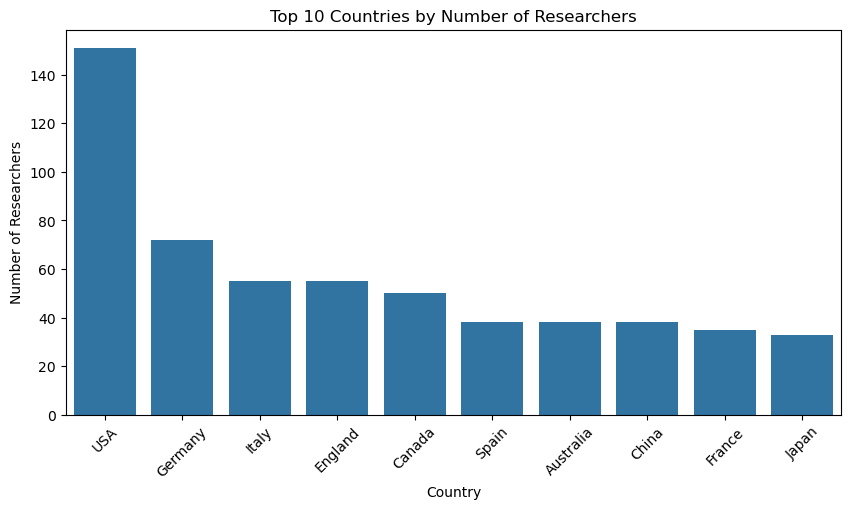

In [20]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_countries.index, y=top_countries.values)

plt.title("Top 10 Countries by Number of Researchers")
plt.xlabel("Country")
plt.ylabel("Number of Researchers")
plt.xticks(rotation=45)

plt.show()

The distribution of researchers across countries shows that certain regions have a higher concentration of Multiple Sclerosis experts. This indicates geographic hubs of research activity and expertise, which can support strategic decision-making in clinical collaborations and medical affairs planning.

2 - Top 5 Specialties across top 5 Countries

In [21]:
top_countries = df["Country"].value_counts().head(5).index

In [22]:
top_specialties = df["Speciality"].value_counts().head(5).index

In [23]:
df_filtered = df[
    (df["Country"].isin(top_countries)) &
    (df["Speciality"].isin(top_specialties))
]

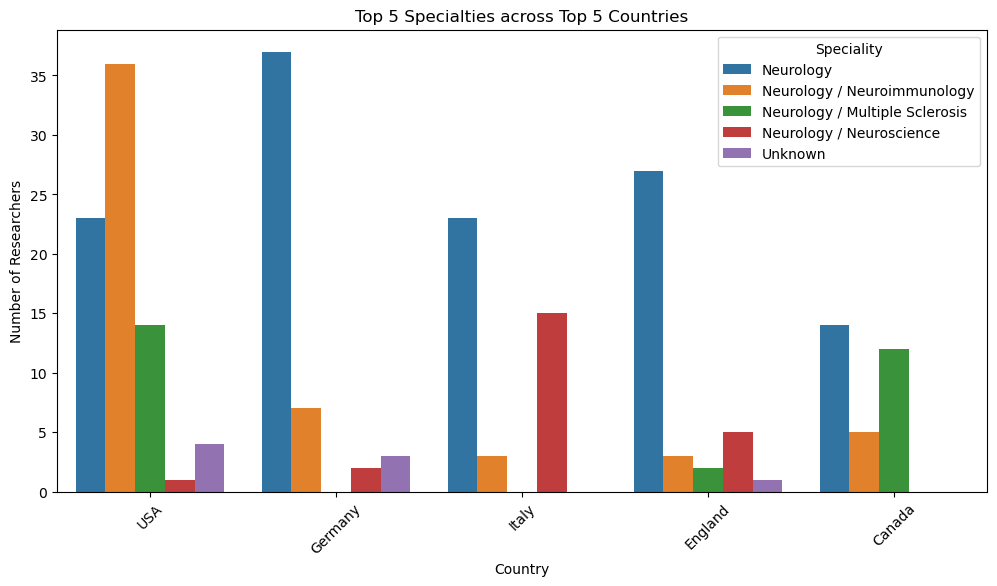

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_filtered,
    x="Country",
    hue="Speciality",
    order=top_countries   # THIS ensures descending order
)

plt.title("Top 5 Specialties across Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Researchers")
plt.xticks(rotation=45)

plt.legend(title="Speciality")
plt.show()

This visualization compares the distribution of the top 5 specialties across different countries. It highlights how expertise varies geographically, helping identify dominant specialties in specific regions and potential gaps in specialization.

3 - Top Specialties across USA States

In [25]:
df_usa = df[df["Country"] == "USA"]

In [26]:
top_states = df_usa["State"].value_counts().head(10).index
top_specialties = df_usa["Speciality"].value_counts().head(5).index

df_filtered = df_usa[
    (df_usa["State"].isin(top_states)) &
    (df_usa["Speciality"].isin(top_specialties))
]

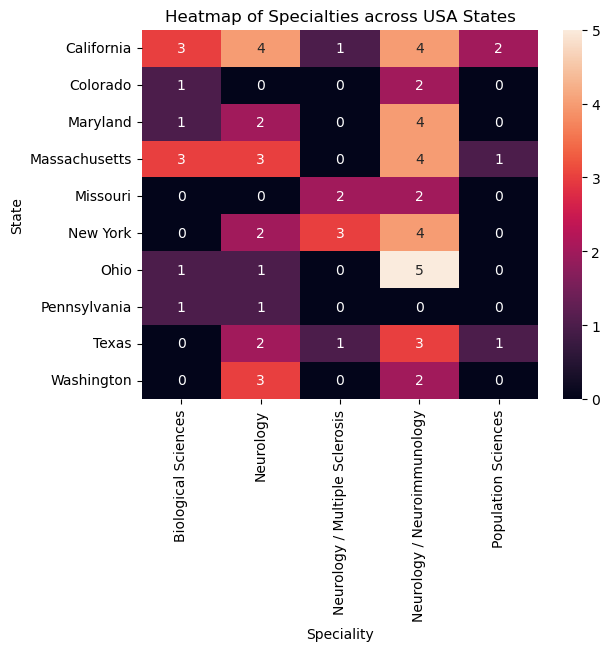

In [27]:
pivot = pd.crosstab(df_filtered["State"], df_filtered["Speciality"])

sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Heatmap of Specialties across USA States")
plt.show()

This visualization analyzes the distribution of experts across different states in the United States, categorized by specialty. It highlights regional differences in expertise and identifies states with high concentrations of specific specialties, which can support targeted healthcare and research strategies.

4 - Top 10 Researchers by Activity Distribution

In [28]:
top10 = df.sort_values(
    by="Total number of activities captured", 
    ascending=False
).head(10)

In [29]:
cols = [
    "Name",
    "Total number of publications-overall",
    "Number of Congress activity points",
    "Number of Guideline Activities",
    "Number of Journal Ed Board Activities",
    "Number of Organisation Activities",
    "Number of Clinical Trial Activities"
]

top10_data = top10[cols]

In [30]:
top10_melted = top10_data.melt(
    id_vars="Name",
    var_name="Activity Type",
    value_name="Count"
)

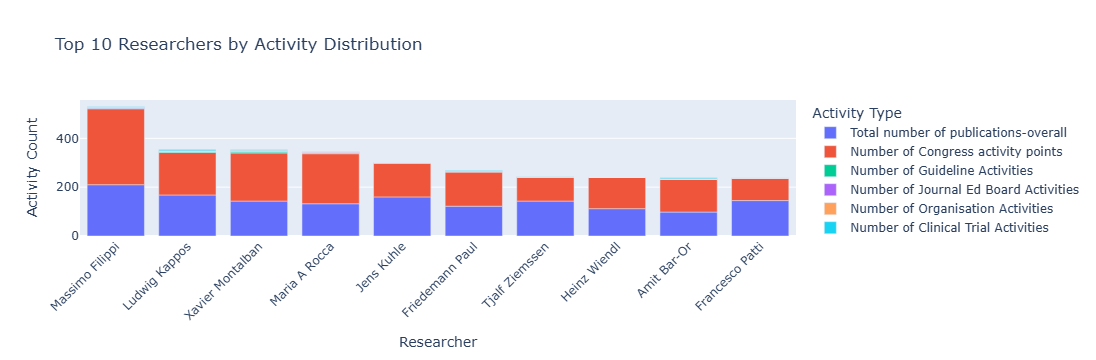

In [31]:
import plotly.express as px

fig = px.bar(
    top10_melted,
    x="Name",
    y="Count",
    color="Activity Type",
    title="Top 10 Researchers by Activity Distribution",
)

fig.update_layout(
    xaxis_title="Researcher",
    yaxis_title="Activity Count",
    xaxis_tickangle=-45
)

fig.show()

This visualization highlights the top 10 researchers based on total activity and provides a detailed breakdown of their contributions across multiple domains such as publications, congress participation, guidelines, editorial roles, organizational involvement, and clinical trials. It enables comparison of individual researcher profiles and helps identify patterns in engagement across different areas of the healthcare ecosystem.

5 - Top 1 Researcher Activity Distribution

In [32]:
top1 = df.sort_values(
    by="Total number of activities captured", 
    ascending=False
).head(1)

In [33]:
labels = [
    "Publications",
    "Congress",
    "Guidelines",
    "Editorial Board",
    "Organisation",
    "Clinical Trials"
]

values = [
    top1["Total number of publications-overall"].values[0],
    top1["Number of Congress activity points"].values[0],
    top1["Number of Guideline Activities"].values[0],
    top1["Number of Journal Ed Board Activities"].values[0],
    top1["Number of Organisation Activities"].values[0],
    top1["Number of Clinical Trial Activities"].values[0]
]

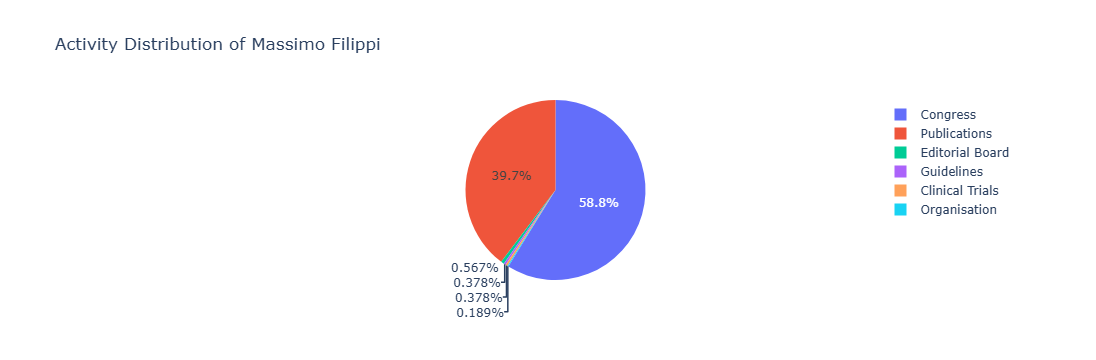

In [34]:
import plotly.express as px

fig = px.pie(
    names=labels,
    values=values,
    title=f"Activity Distribution of {top1['Name'].values[0]}"
)

fig.show()

A pie chart was used to visualize the distribution of activity types for top researchers. It highlights the proportion of contributions across different domains such as publications, congress activities, and clinical trials, providing insights into individual researcher focus areas.

6 - Topic-wise Activity Distribution for massimo filippi

In [35]:
massimo = df[df["Name"].str.contains("Massimo", case=False, na=False)]

In [36]:
topics = [
    "Prognostic_Evaluation_Congress", "Prognostic_Evaluation_Publications",
    "Innovators_Congress", "Innovators_Publications",
    "Novel_therapies_Congress", "Novel_therapies_Publications",
    "Existing_therapies_Congress", "Existing_therapies_Publications",
    "Biomarker_Congress", "Biomarker_Publications",
    "Inflammation_Congress", "Inflammation_Publications",
    "RWE_Congress", "RWE_Publications",
    "Unmet_needs_Congress", "Unmet_needs_Publications",
    "BTK_Congress", "BTK_Publications",
    "CAR_T_Congress", "CAR_T_Publications"
]

In [37]:
import pandas as pd

massimo_data = massimo[topics].T.reset_index()
massimo_data.columns = ["Topic_Type", "Value"]

In [38]:
massimo_data["Topic"] = massimo_data["Topic_Type"].str.replace("_Congress", "", regex=False)
massimo_data["Topic"] = massimo_data["Topic"].str.replace("_Publications", "", regex=False)

massimo_data["Type"] = massimo_data["Topic_Type"].apply(
    lambda x: "Congress" if "Congress" in x else "Publications"
)

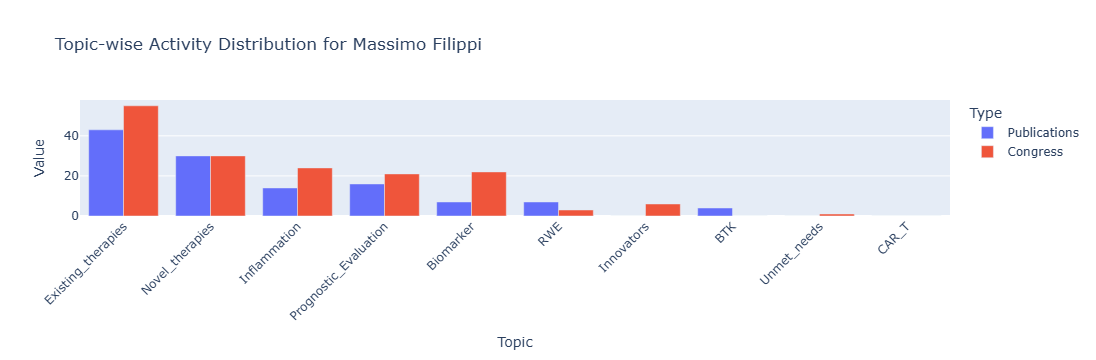

In [39]:
massimo_data["Total"] = massimo_data.groupby("Topic")["Value"].transform("sum")

fig = px.bar(
    massimo_data.sort_values("Total", ascending=False),
    x="Topic",
    y="Value",
    color="Type",
    barmode="group",
    title=f"Topic-wise Activity Distribution for {massimo['Name'].values[0]}"
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

This visualization focuses on the top expert and compares their contributions across different Multiple Sclerosis research topics. It distinguishes between congress and publication activities, highlighting areas of strong expertise and engagement. This helps in understanding the researcher’s specialization and contribution patterns across different domains.

7 - Top 100 Experts by Total Activity

In [40]:
top100 = df.sort_values(
    by="Total number of activities captured", 
    ascending=False
).head(100)

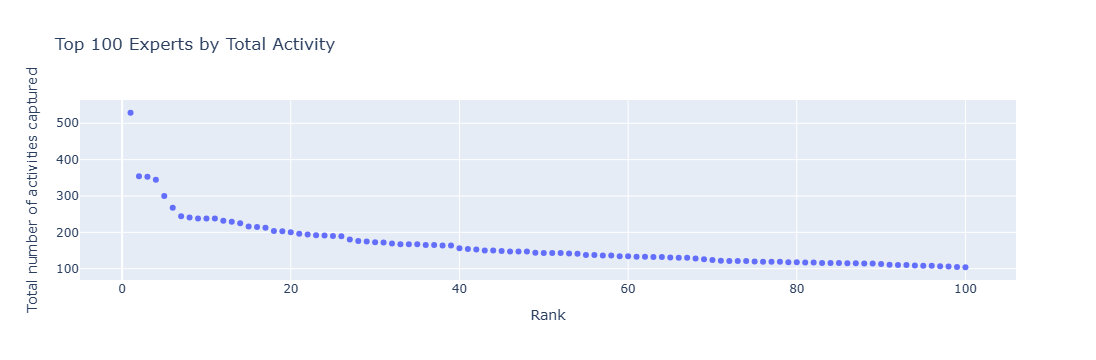

In [41]:
top100["Rank"] = range(1, 101)

fig = px.scatter(
    top100,
    x="Rank",
    y="Total number of activities captured",
    hover_name="Name",
    title="Top 100 Experts by Total Activity"
)

fig.show()

This scatter plot visualizes the distribution of total activities among the top 100 experts. It helps identify patterns such as highly active outliers and the overall spread of engagement levels across researchers.

8 - Top 30 Experts in Biomarker: Congress vs Publications

In [42]:
df["Biomarker_Total"] = df["Biomarker_Congress"] + df["Biomarker_Publications"]

In [43]:
top30 = df.sort_values(
    by="Biomarker_Total",
    ascending=False
).head(30)

In [44]:
top30["Rank"] = range(1, 31)

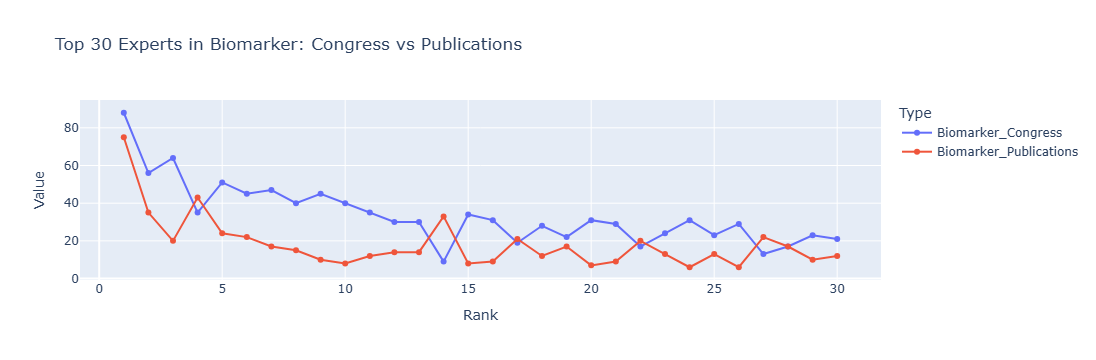

In [45]:
import pandas as pd

top30_melted = top30.melt(
    id_vars=["Name", "Rank"],
    value_vars=["Biomarker_Congress", "Biomarker_Publications"],
    var_name="Type",
    value_name="Value"
)

fig = px.line(
    top30_melted,
    x="Rank",
    y="Value",
    color="Type",
    markers=True,
    hover_name="Name",
    title="Top 30 Experts in Biomarker: Congress vs Publications"
)

fig.show()

This line chart visualizes the top 30 experts based on their activity in the Biomarker domain, combining both congress and publication contributions. It highlights trends in researcher engagement and allows comparison between different types of contributions, providing insights into expertise distribution within this specific topic.

9 - Topic-wise Total Activity for Massimo Filippi

In [46]:
massimo = df[df["Name"].str.contains("Massimo Filippi", case=False, na=False)]
massimo = massimo.head(1)

In [47]:
topics_combined = {
    "Prognostic_Evaluation": ["Prognostic_Evaluation_Congress", "Prognostic_Evaluation_Publications"],
    "Innovators": ["Innovators_Congress", "Innovators_Publications"],
    "Novel_therapies": ["Novel_therapies_Congress", "Novel_therapies_Publications"],
    "Existing_therapies": ["Existing_therapies_Congress", "Existing_therapies_Publications"],
    "Biomarker": ["Biomarker_Congress", "Biomarker_Publications"],
    "Inflammation": ["Inflammation_Congress", "Inflammation_Publications"],
    "RWE": ["RWE_Congress", "RWE_Publications"],
    "Unmet_needs": ["Unmet_needs_Congress", "Unmet_needs_Publications"],
    "BTK": ["BTK_Congress", "BTK_Publications"],
    "CAR_T": ["CAR_T_Congress", "CAR_T_Publications"]
}

In [48]:
topic_values = {}

for topic, cols in topics_combined.items():
    topic_values[topic] = massimo[cols].sum(axis=1).values[0]

In [49]:
import pandas as pd

massimo_topics_df = pd.DataFrame({
    "Topic": list(topic_values.keys()),
    "Total Points": list(topic_values.values())
})

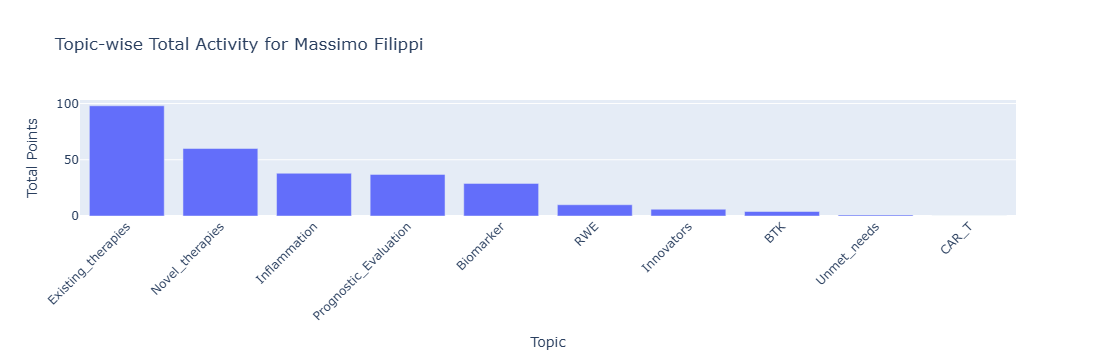

In [50]:
import plotly.express as px

fig = px.bar(
    massimo_topics_df.sort_values("Total Points", ascending=False),
    x="Topic",
    y="Total Points",
    title="Topic-wise Total Activity for Massimo Filippi"
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

This visualization presents the combined activity points (publications and congress contributions) for Massimo Filippi across different research topics. It highlights the areas where the expert has the highest engagement, providing insights into specialization and research focus within Multiple Sclerosis.

10 - Distribution of Total Activities

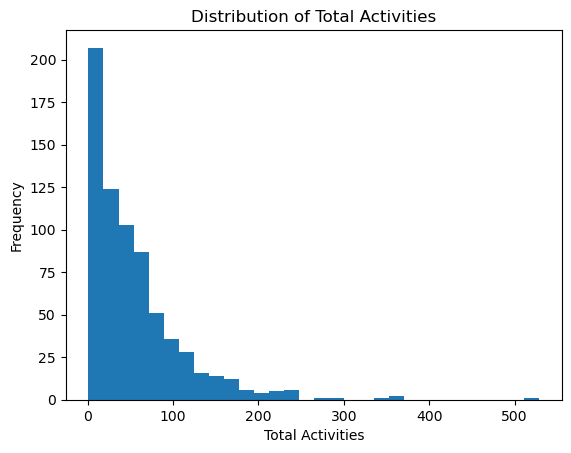

In [51]:
plt.figure()
plt.hist(df["Total number of activities captured"], bins=30)

plt.title("Distribution of Total Activities")
plt.xlabel("Total Activities")
plt.ylabel("Frequency")

plt.show()

This histogram visualizes the distribution of the total number of activities captured across all researchers. It helps in understanding how researcher activity is spread within the dataset.

11 - Top 10 Affiliations by Number of Experts

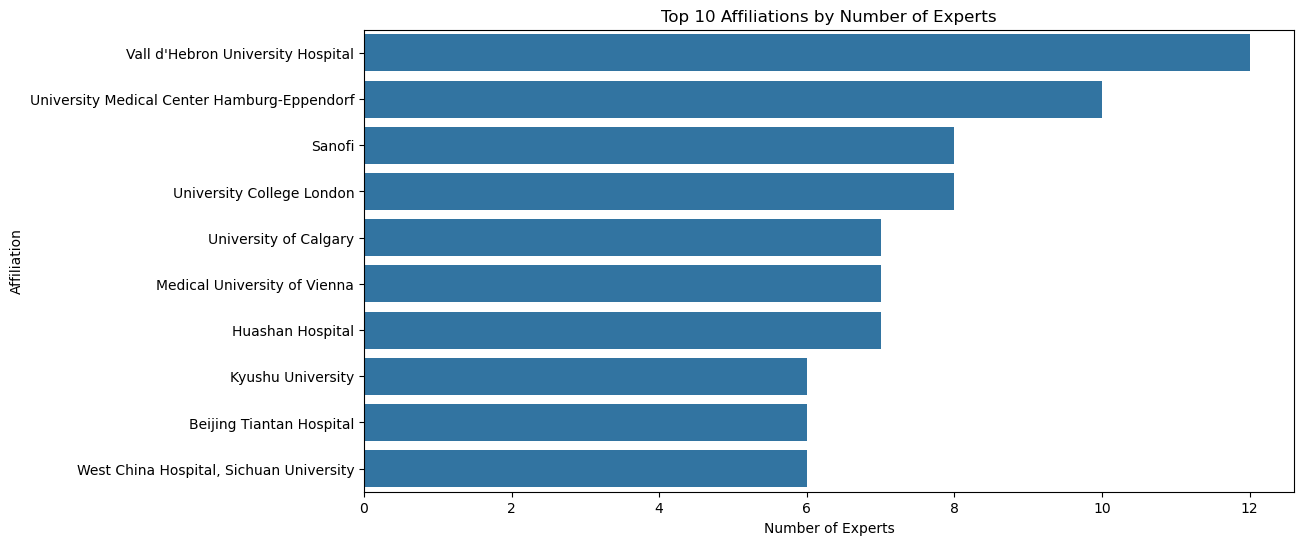

In [55]:
aff_counts = df[df["Primary affiliation"] != "Unknown"]["Primary affiliation"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=aff_counts.values,
    y=aff_counts.index
)

plt.title("Top 10 Affiliations by Number of Experts")
plt.xlabel("Number of Experts")
plt.ylabel("Affiliation")

plt.show()

This visualization highlights the top affiliations with the highest number of experts in the dataset. It helps identify leading research institutions and centers of excellence in Multiple Sclerosis, which can be important for collaboration and strategic decision-making in healthcare.

Task 4

Summary of Key Insights

The exploratory data analysis of the Multiple Sclerosis researcher dataset reveals meaningful patterns in researcher activity, geographic distribution, specialization, and institutional concentration. The findings highlight how expertise and engagement are distributed across the global healthcare research landscape.

Key Observations:

1 - Concentration of Activity Among Top Experts
A small group of researchers contributes a disproportionately high number of activities. This indicates the presence of highly influential key opinion leaders (KOLs) who drive a significant portion of research and clinical engagement.

2- Geographic Distribution of Expertise
Certain countries dominate in terms of researcher count, suggesting strong regional hubs of Multiple Sclerosis research. Within the United States, specific states show higher concentrations of experts, pointing to localized centers of excellence. 

3 - Specialty Distribution Patterns
A limited number of specialties account for the majority of researchers, while others are underrepresented. This imbalance highlights potential opportunities to expand research efforts in less represented domains.

4 - Topic-Level Insights and Research Focus
Analysis of topic-specific activities shows that areas such as Biomarker research, Novel therapies, Prognostic evaluation have higher engagement levels.
This indicates current trends and priority areas in Multiple Sclerosis research.

5 - Activity Distribution and Outliers
The overall distribution of activities is positively skewed, with Most researchers having moderate activity levels and A few exhibiting exceptionally high engagement. This confirms the presence of outliers and uneven contribution patterns.

6 - Institutional Dominance
Certain affiliations have a higher number of experts, highlighting leading research institutions and potential collaboration hubs in the field.

Conclusion:

Overall, the analysis demonstrates that Multiple Sclerosis research is driven by a combination of highly active experts, region-specific hubs, and topic-focused specialization. These insights can support strategic decision-making in healthcare, including collaboration planning, resource allocation, and identification of emerging research areas.